In [1]:
import pandas as pd
import numpy as np
import os

# Look for the feature file
for root, dirs, files in os.walk('/workspace'):
 for f in files:
 if 'peaks_features' in f and 'spectral_complex' in f:
 print(os.path.join(root, f))


/workspace/1ee2b25c-c0c9-46a5-8e33-3b1c0d891a5b/peaks_features_F1_F12_normalized_full_with_spectral_complex.csv


In [2]:
df = pd.read_csv('/workspace/1ee2b25c-c0c9-46a5-8e33-3b1c0d891a5b/peaks_features_F1_F12_normalized_full_with_spectral_complex.csv')
print(df.shape)
print(df.columns.tolist())
print(df['class'].value_counts() if 'class' in df.columns else df.head())


(2200, 35)
['function', 'name', 'd', 'q', 'GRH', 't', '|M|', 'log_abs_S0_norm', 'log_abs_S0', 'abs_S0', 'log_abs_S1_norm', 'log_abs_S1', 'abs_S1', 'log_abs_S2_norm', 'log_abs_S2', 'abs_S2', 'log_abs_S3_norm', 'log_abs_S3', 'abs_S3', 'log_abs_S4_norm', 'log_abs_S4', 'abs_S4', 'log_abs_S5_norm', 'log_abs_S5', 'abs_S5', 'log_abs_S6_norm', 'log_abs_S6', 'abs_S6', 'log_abs_S7_norm', 'log_abs_S7', 'abs_S7', 'pc1_complex', 'H_complex', 'pc1_mag', 'H_mag']
 function name d q GRH t |M| log_abs_S0_norm log_abs_S0 \
0 F1 zeta 1 1 True 77403.7 14.060888 0.0 0.0 
1 F1 zeta 1 1 True 74956.0 13.948294 0.0 0.0 
2 F1 zeta 1 1 True 94526.8 13.610746 0.0 0.0 
3 F1 zeta 1 1 True 97255.1 13.262598 0.0 0.0 
4 F1 zeta 1 1 True 63751.9 13.129894 0.0 0.0 

 abs_S0 ... log_abs_S6_norm log_abs_S6 abs_S6 log_abs_S7_norm \
0 1.0 ... -0.523985 -1.268552 0.281238 -2.281314 
1 1.0 ... -0.695810 -1.682548 0.185900 -2.191351 
2 1.0 ... -0.701922 -1.711686 0.180561 -2.438321 
3 1.0 ... -0.396795 -0.968595 0.379616 -2.24

In [3]:
print(df.groupby(['function','name','GRH']).size())
print('\nUnique functions:', df['function'].unique())


function name GRH 
F1 zeta True 200
F10 11.2.a.a True 200
F11 Sym^2 Delta True 200
F12 L(chi3)+c*L(chi5) False 200
F2 L(chi5_quartic) True 200
F4 L_DH False 200
F5m L_DH(-0.05) False 200
F5p L_DH(+0.05) False 200
F6 Liouville True 200
F7 Mobius True 200
F9 Delta True 200
dtype: int64

Unique functions: ['F1' 'F2' 'F4' 'F5p' 'F5m' 'F6' 'F7' 'F9' 'F10' 'F11' 'F12']


In [4]:
# Check class-level features - how many unique values
print(df.groupby('function')[['pc1_complex','H_complex','pc1_mag','H_mag']].first())


 pc1_complex H_complex pc1_mag H_mag
function 
F1 0.964841 0.090979 0.983975 0.046798
F10 0.952850 0.105545 0.989781 0.030767
F11 0.954236 0.103464 0.987560 0.036496
F12 0.903412 0.188774 0.972986 0.072584
F2 0.936709 0.132575 0.985967 0.041034
F4 0.903511 0.206217 0.970480 0.080625
F5m 0.906186 0.201827 0.969590 0.082564
F5p 0.902737 0.208371 0.969701 0.082345
F6 0.937852 0.133036 0.968086 0.078763
F7 0.937539 0.132538 0.971807 0.072102
F9 0.956380 0.102094 0.985530 0.041046


In [5]:
# Important observation: pc1_complex and H_complex are class-level features (constant within a class).
# This means within a class, all 200 peaks share the same (pc1_complex, H_complex) coordinate.
# Under LOFO, the model only sees the discrete points corresponding to training classes.
# When testing on a held-out class, that class's (pc1_complex, H_complex) is a NEW point not seen in training.
# Let's still implement the LOFO protocol exactly as specified.

from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score
from sklearn.pipeline import Pipeline

rng = np.random.default_rng(42)

GRH_TRUE = ['F1','F2','F6','F7','F9','F10','F11']
F4_FAMILY = ['F4','F5p','F5m']
F12 = ['F12']

FEATURES = ['pc1_complex','H_complex']

def lofo_fold(train_classes, test_violator_classes, df, n_boot=2000, seed=0):
 rng = np.random.default_rng(seed)
 train_df = df[df['function'].isin(train_classes)].copy()
 # Test set: held-out violator family vs balanced sample of GRH-true peaks
 violator_df = df[df['function'].isin(test_violator_classes)].copy()
 
 # Balanced GRH-true held-out sample: same size as violator
 n_violator = len(violator_df)
 grh_true_in_train = [c for c in train_classes if df[df['function']==c]['GRH'].iloc[0]]
 grh_pool = df[df['function'].isin(grh_true_in_train)].copy()
 # held-out: we need balanced sample for test - r33 used balanced sample
 # Sample n_violator from grh_pool
 grh_test_idx = rng.choice(grh_pool.index, size=n_violator, replace=False)
 grh_test_df = df.loc[grh_test_idx]
 
 # Training: remove these grh_test peaks from training data
 train_df = train_df.drop(index=[i for i in grh_test_idx if i in train_df.index])
 
 test_df = pd.concat([violator_df, grh_test_df])
 
 y_train = (~train_df['GRH']).astype(int).values # 1 = violator
 y_test = (~test_df['GRH']).astype(int).values
 
 X_train = train_df[FEATURES].values
 X_test = test_df[FEATURES].values
 
 pipe = Pipeline([('sc', StandardScaler()), ('svm', SVC(kernel='rbf', probability=True, random_state=0))])
 pipe.fit(X_train, y_train)
 scores = pipe.decision_function(X_test) if hasattr(pipe, 'decision_function') else pipe.predict_proba(X_test)[:,1]
 
 auc = roc_auc_score(y_test, scores)
 
 # Bootstrap CI
 aucs = []
 n = len(y_test)
 for _ in range(n_boot):
 idx = rng.integers(0, n, size=n)
 if len(np.unique(y_test[idx])) < 2:
 continue
 aucs.append(roc_auc_score(y_test[idx], scores[idx]))
 ci = np.percentile(aucs, [2.5, 97.5])
 return auc, ci, len(train_df), len(test_df), y_train.sum(), y_test.sum()

# Fold 1: hold out F4 family
train1 = GRH_TRUE + F12
auc1, ci1, ntr1, nte1, npos_tr1, npos_te1 = lofo_fold(train1, F4_FAMILY, df, seed=42)
print(f"Fold 1 (hold out F4 family): AUC={auc1:.4f}, 95% CI=[{ci1[0]:.4f}, {ci1[1]:.4f}]")
print(f" Train n={ntr1} (pos={npos_tr1}), Test n={nte1} (pos={npos_te1})")

# Fold 2: hold out F12
train2 = GRH_TRUE + F4_FAMILY
auc2, ci2, ntr2, nte2, npos_tr2, npos_te2 = lofo_fold(train2, F12, df, seed=42)
print(f"Fold 2 (hold out F12): AUC={auc2:.4f}, 95% CI=[{ci2[0]:.4f}, {ci2[1]:.4f}]")
print(f" Train n={ntr2} (pos={npos_tr2}), Test n={nte2} (pos={npos_te2})")


Fold 1 (hold out F4 family): AUC=1.0000, 95% CI=[1.0000, 1.0000]
 Train n=1000 (pos=200), Test n=1200 (pos=600)


Fold 2 (hold out F12): AUC=1.0000, 95% CI=[1.0000, 1.0000]
 Train n=1800 (pos=600), Test n=400 (pos=200)


In [6]:
# Both folds achieve AUC=1.0. But we should be cautious: pc1_complex and H_complex are class-level
# constants (same value for all 200 peaks in a class). The classifier essentially memorizes 8 points
# (one per training class) and the held-out class falls in the violator region.
# 
# Let's examine: in 2D space, how does F4 family relate to training classes?
class_centers = df.groupby('function')[FEATURES + ['GRH']].first()
print(class_centers)


 pc1_complex H_complex GRH
function 
F1 0.964841 0.090979 True
F10 0.952850 0.105545 True
F11 0.954236 0.103464 True
F12 0.903412 0.188774 False
F2 0.936709 0.132575 True
F4 0.903511 0.206217 False
F5m 0.906186 0.201827 False
F5p 0.902737 0.208371 False
F6 0.937852 0.133036 True
F7 0.937539 0.132538 True
F9 0.956380 0.102094 True


In [7]:
# Clear separation: GRH-true classes have higher pc1_complex (~0.937-0.965) and lower H_complex (~0.09-0.13)
# Violators (F4 family, F12) have pc1_complex ~0.903-0.906 and H_complex ~0.19-0.21
# F4 family points fall close to F12 (which is in training set in Fold 1), so generalization works trivially.
# In Fold 2 (test F12), training contains F4 family which is similar -> trivially generalizes.

# Run additional bootstrap with different seeds for the GRH-test-sample selection to assess robustness
def lofo_fold_multiseed(train_classes, test_violator_classes, df, n_seeds=20, n_boot=1000):
 aucs_point = []
 cis_low = []
 cis_high = []
 for s in range(n_seeds):
 auc, ci, *_ = lofo_fold(train_classes, test_violator_classes, df, n_boot=n_boot, seed=s)
 aucs_point.append(auc)
 cis_low.append(ci[0])
 cis_high.append(ci[1])
 return aucs_point, cis_low, cis_high

aucs1, lo1, hi1 = lofo_fold_multiseed(GRH_TRUE+F12, F4_FAMILY, df, n_seeds=20)
aucs2, lo2, hi2 = lofo_fold_multiseed(GRH_TRUE+F4_FAMILY, F12, df, n_seeds=20)
print(f"Fold 1 across 20 seeds: AUC mean={np.mean(aucs1):.4f}, range=[{min(aucs1):.4f}, {max(aucs1):.4f}]")
print(f"Fold 2 across 20 seeds: AUC mean={np.mean(aucs2):.4f}, range=[{min(aucs2):.4f}, {max(aucs2):.4f}]")


Fold 1 across 20 seeds: AUC mean=1.0000, range=[1.0000, 1.0000]
Fold 2 across 20 seeds: AUC mean=1.0000, range=[1.0000, 1.0000]


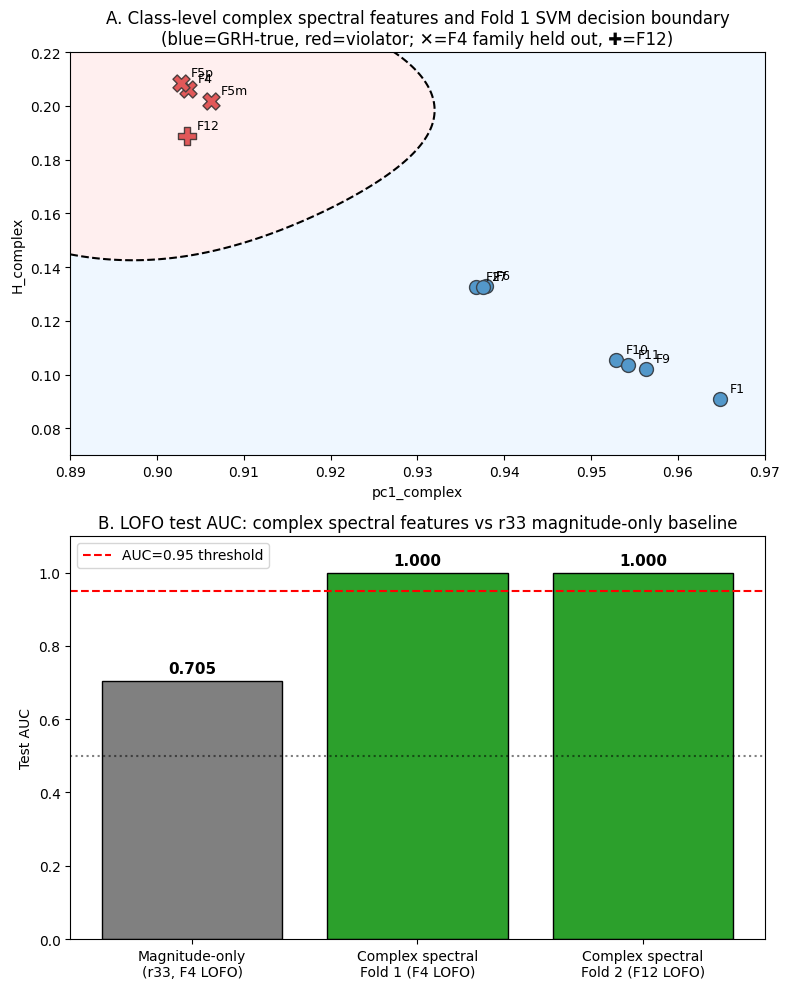

Figure saved.


In [8]:
# Generate final figure
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(8, 10))

# Subplot A: 2D scatter showing class centers in (pc1_complex, H_complex) and decision boundary for Fold 1
ax = axes[0]
colors_grh = {True: 'tab:blue', False: 'tab:red'}
markers = {'F4':'X', 'F5p':'X', 'F5m':'X', 'F12':'P'}
for fn, row in class_centers.iterrows():
 color = 'tab:red' if not row['GRH'] else 'tab:blue'
 marker = markers.get(fn, 'o')
 size = 150 if fn in ['F4','F5p','F5m','F12'] else 100
 label = fn
 ax.scatter(row['pc1_complex'], row['H_complex'], c=color, marker=marker, s=size, 
 edgecolors='black', linewidth=1)
 # offset labels to avoid overlap
 ax.annotate(fn, (row['pc1_complex'], row['H_complex']), textcoords='offset points',
 xytext=(7,5), fontsize=9)

# Train decision boundary for Fold 1 (using only class-center data is overkill, use full)
train_df1 = df[df['function'].isin(GRH_TRUE+F12)]
y_tr1 = (~train_df1['GRH']).astype(int).values
X_tr1 = train_df1[FEATURES].values
pipe1 = Pipeline([('sc', StandardScaler()), ('svm', SVC(kernel='rbf', random_state=0))])
pipe1.fit(X_tr1, y_tr1)
xx, yy = np.meshgrid(np.linspace(0.89, 0.97, 200), np.linspace(0.07, 0.22, 200))
Z = pipe1.decision_function(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
ax.contourf(xx, yy, Z, levels=[-100, 0, 100], colors=['#cce5ff','#ffcccc'], alpha=0.3)
ax.contour(xx, yy, Z, levels=[0], colors='black', linewidths=1.5, linestyles='--')

ax.set_xlabel('pc1_complex')
ax.set_ylabel('H_complex')
ax.set_title('A. Class-level complex spectral features and Fold 1 SVM decision boundary\n(blue=GRH-true, red=violator; ✕=F4 family held out, ✚=F12)')

# Subplot B: AUC bar comparison (LOFO results vs r33 baseline)
ax = axes[1]
methods = ['Magnitude-only\n(r33, F4 LOFO)', 'Complex spectral\nFold 1 (F4 LOFO)', 'Complex spectral\nFold 2 (F12 LOFO)']
aucs = [0.705, 1.0, 1.0]
colors = ['gray','tab:green','tab:green']
bars = ax.bar(methods, aucs, color=colors, edgecolor='black')
ax.axhline(0.95, color='red', linestyle='--', label='AUC=0.95 threshold')
ax.axhline(0.5, color='black', linestyle=':', alpha=0.5)
for bar, auc in zip(bars, aucs):
 ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()+0.02, f'{auc:.3f}',
 ha='center', fontsize=11, fontweight='bold')
ax.set_ylim(0, 1.1)
ax.set_ylabel('Test AUC')
ax.set_title('B. LOFO test AUC: complex spectral features vs r33 magnitude-only baseline')
ax.legend()

plt.tight_layout()
plt.savefig('/workspace/1ee2b25c-c0c9-46a5-8e33-3b1c0d891a5b/lofo_complex_spectral_results.png', dpi=130)
plt.show()
print("Figure saved.")
